<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDA0321ENSkillsNetwork928-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Hands-on Lab : Web Scraping**


Estimated time needed: **30 to 45** minutes


## Objectives


In this lab you will perform the following:


* Extract information from a given web site 
* Write the scraped data into a csv file.


## Extract information from the given web site
You will extract the data from the below web site: <br> 


In [1]:
#this url contains the data you need to scrape
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/labs/datasets/Programming_Languages.html"

The data you need to scrape is the **name of the programming language** and **average annual salary**.<br> It is a good idea to open the url in your web broswer and study the contents of the web page before you start to scrape.


Import the required libraries


In [2]:
# Your code here
import requests
from bs4 import BeautifulSoup as BS, SoupStrainer as SS
import pandas as pd

Download the webpage at the url


In [3]:
#your code goes here
response = requests.get(url)

Create a soup object


In [4]:
#your code goes here
tables = SS("table")
soup = BS(response.text, features="html.parser", parse_only=tables)
table = soup.find("table")

Scrape the `Language name` and `annual average salary`.


In [5]:
#your code goes here
rows = []
for raw_row in table.find_all("tr"):
    row = [cell.get_text(strip=True) for cell in raw_row.find_all("td")]
    rows.append(row)
df = pd.DataFrame([[row[1], row[3]] for row in rows[1:]], columns = [rows[0][1], rows[0][3]])
df
# first and third columns are requested.

,Language,Average Annual Salary
0,Python,"$114,383"
1,Java,"$101,013"
2,R,"$92,037"
3,Javascript,"$110,981"
4,Swift,"$130,801"
5,C++,"$113,865"
6,C#,"$88,726"
7,PHP,"$84,727"
8,SQL,"$84,793"
9,Go,"$94,082"


Save the scrapped data into a file named *popular-languages.csv*


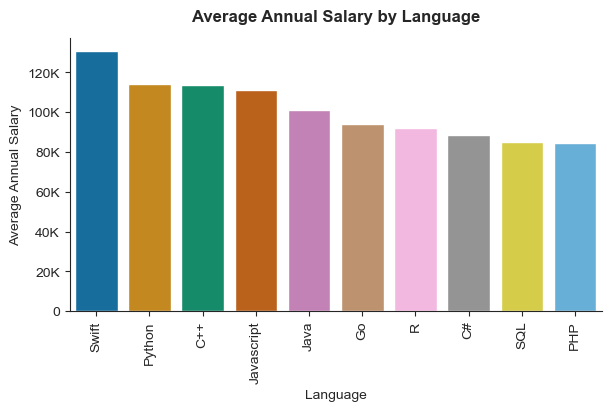

In [6]:
df["Average Annual Salary"].dtype
df["Average Annual Salary"] = df["Average Annual Salary"].str.replace({"$": "", ",": ""})
df["Average Annual Salary"].dtype
df["Average Annual Salary"] = df["Average Annual Salary"].astype("float")
df["Average Annual Salary"].dtype
# df["Average Annual Salary"] = df["Average Annual Salary"].round(0)

import seaborn as sns
import matplotlib.pyplot as plt 
import numpy as np
sns.set_style("ticks")
plt.rc("axes.spines", top=False, right=False)

fig, ax = plt.subplots(figsize=(6, 4), layout="constrained")
sns.barplot(data=df.sort_values("Average Annual Salary", ascending=False),
			x="Language",
			y="Average Annual Salary",
			hue="Language",
			palette="colorblind",
			ax=ax)
plt.xticks(rotation=90)
plt.yticks(ticks=np.arange(0, 120001, 20000),
		   labels=["0", "20K", "40K", "60K", "80K", "100K", "120K"])
plt.title("Average Annual Salary by Language", fontweight=700, y=1.03);

fig.savefig("lang.png")

In [7]:
# your code goes here
df.to_csv("popular_languages.csv", encoding="utf-8", index=False)

## Authors


Ramesh Sannareddy


### Other Contributors


Rav Ahuja


## Change Log


|  Date (YYYY-MM-DD) |  Version | Changed By  |  Change Description |
|---|---|---|---|
| 2020-10-17  | 0.1  | Ramesh Sannareddy  |  Created initial version of the lab |


 Copyright &copy; 2020 IBM Corporation. This notebook and its source code are released under the terms of the [MIT License](https://cognitiveclass.ai/mit-license/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDA0321ENSkillsNetwork928-2022-01-01).
